In [226]:
import pandas as pd
from numpy import *
from matplotlib.pyplot import *

In [227]:
df = pd.read_csv("Data.csv")
df.to_markdown("Data.md")

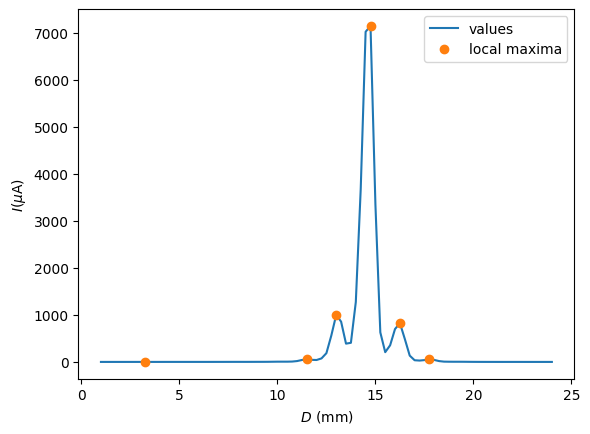

In [228]:

I = df["I"].values #micro ampere
D = df["D"].values #mm
xlabel("$D$ (mm)")
ylabel(r"$I (\mu \text{A})$")
Is = convolve(df["I"],array([1,2,1])/4)[1:-1]
pmax = argmax(I)
I = Is
plot(D,I)
#figure()
#plot(D,Is)
eps = 0.1
peaks = [i for i in range(1,len(D)-1) if (I[i] - I[i-1])>eps*I[i] and (I[i] - I[i+1])>eps*I[i]]
peaks.append(pmax)
peaks = sorted(peaks)
nvals = [-3,-2,-1,0,1,2]
plot(D[peaks],I[peaks],'o')
Dn = [nvals,D[peaks]]
legend(["values",'local maxima'])

array([[-2.  , -3.25],
       [-1.  , -1.75],
       [ 0.  ,  0.  ],
       [ 1.  ,  1.5 ],
       [ 2.  ,  3.  ]])

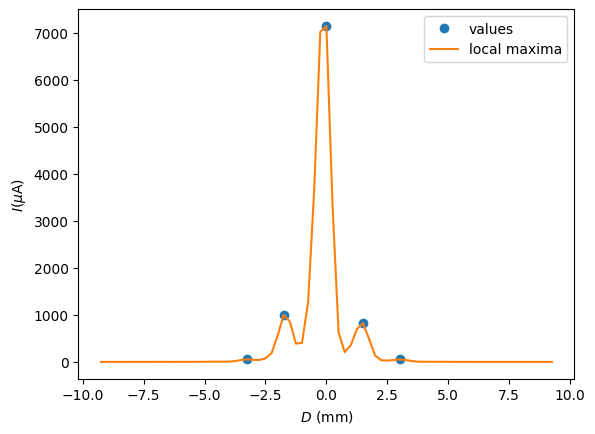

In [229]:
Dn = array(Dn).T
Dn = Dn[1:]
central = Dn[2]
Dn = Dn - central
D = D - central[1]
peaks = peaks[1:]
plot(D[peaks],I[peaks],'o')
I = I[len(D)//5:]
D = D[len(D)//5:]
plot(D,I)
xlabel("$D$ (mm)")
ylabel(r"$I (\mu \text{A})$")
legend(["values",'local maxima'])
Dn

In [230]:
central = Dn[2]
print(central)

[0. 0.]


In [231]:
DistFromCent = Dn

In [232]:
DistFromCent_abs = abs(DistFromCent[:, 1])
eps = 1e-10
X = DistFromCent_abs + eps

In [233]:
L = 1094

In [234]:
theta = arctan(X/L)

Text(0, 0.5, '$\\theta_n$')

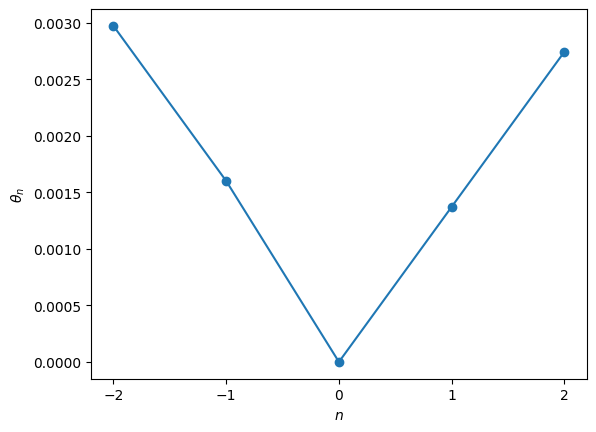

In [235]:
plot(Dn[:,0],theta,'-o')
xticks(Dn[:,0])
xlabel("$n$")
ylabel(r"$\theta_n$")

Text(0, 0.5, '$\\Lambda_n$ (mm)')

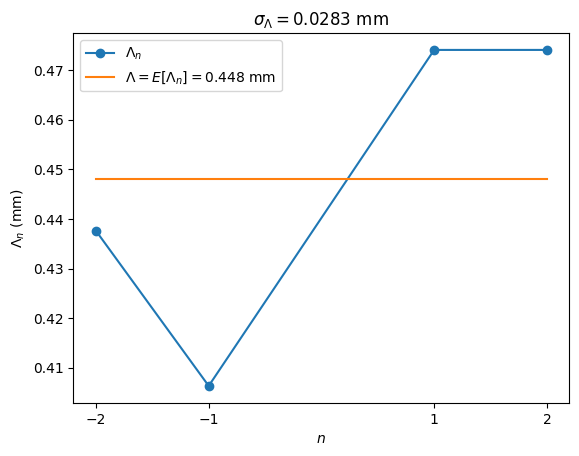

In [236]:
lamb = 650e-6 #mm
nvals = Dn[:,0][[0,1,3,4]]
Lamb = abs(nvals) * lamb / sin(theta[[0,1,3,4]])
plot(nvals,Lamb,'-o')
plot([-2,2],[mean(Lamb),mean(Lamb)])
xticks(nvals)
legend(["$\Lambda_n$","$\Lambda = E[\Lambda_n] = "+f"{round(mean(Lamb),4)}$ mm"])
title("$ \sigma_{\Lambda} = "+f"{round(var(Lamb)**0.5,4)}$ mm")
xlabel("$n$")
ylabel("$\Lambda_n$ (mm)")

K mean =  5.422629773894898e-10
beta mean =  1874665175.7416162
K sd =  7.137289231896312e-11
beta sd =  232756886.43502727


Text(0.5, 1.0, '$ \\sigma_V = 86.3001$ m/s')

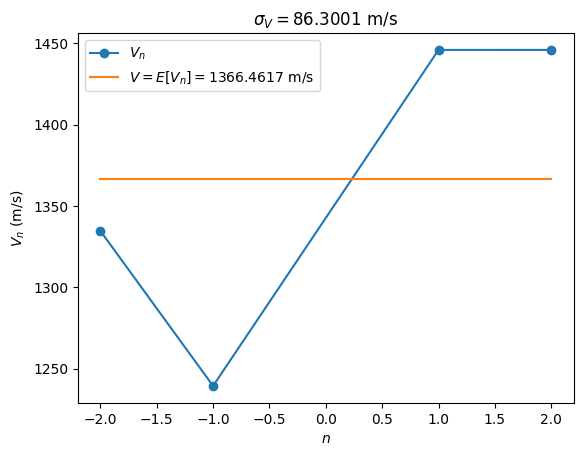

In [237]:
freq = 3.05e6 #Hz
V = freq * Lamb / 1000 #m/s
rho = 1000 #kgm^-3
beta = rho * V **2
K = 1/beta
beta_mean = mean(beta)
K_mean = mean(K)
beta_sd = var(beta)**0.5
K_sd = var(K)**0.5
print("K mean = ",K_mean)
print("beta mean = ",beta_mean)
print("K sd = ",K_sd)
print("beta sd = ",beta_sd)
plot(nvals,V,'-o')
plot([-2,2],[mean(V),mean(V)])
xlabel("$n$")
ylabel("$V_n$ (m/s)")
legend(["$V_n$","$V = E[V_n] = "+f"{round(mean(V),4)}$ m/s"])
title("$ \sigma_V = "+f"{round(var(V)**0.5,4)}$ m/s")


In [238]:
LC = 0.01 #mm
err = 0.5 * abs(nvals) * lamb * L * (DistFromCent_abs[[0,1,3,4]] ** -2) * LC
print(err) # mm
print(mean(err))

[0.00067323 0.00116098 0.00158022 0.00079011]
0.0010511359236002093


In [239]:
beta = rho * mean(V)**2
K = 1/beta
print("beta =",beta)
print("K =",K)
print("dB = ",2 * rho * mean(V) * (var(V)**0.5))
print("dK = ",2 * (var(V) ** 0.5)/ (rho * mean(V)**3))

beta = 1867217476.0450408
K = 5.355562556741398e-10
dB =  235851436.5424192
dK =  6.764702766041278e-11
